In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Keras imports
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.applications import EfficientNetB7
from keras.callbacks import ReduceLROnPlateau
from keras.utils import image_dataset_from_directory
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

# Updated ImageDataGenerator import
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

# Sklearn imports
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# General imports
import random
import keras

import shutil

2026-04-08 07:46:09.590847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775634369.823132      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775634369.889411      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775634370.403388      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775634370.403435      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775634370.403439      55 computation_placer.cc:177] computation placer alr

In [3]:
# Define paths
data_path = '/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES'
output_path = '/kaggle/working/Skin-disease-images'


# Remove the existing dataset from the working directory if it exists
if os.path.exists(output_path):
    shutil.rmtree(output_path)

# Copy the dataset to a writable directory
if not os.path.exists(output_path):
    shutil.copytree(data_path, output_path)

Class counts: [3140, 1257, 1677, 2055, 2103, 3323, 2079, 1847, 1702, 7970]


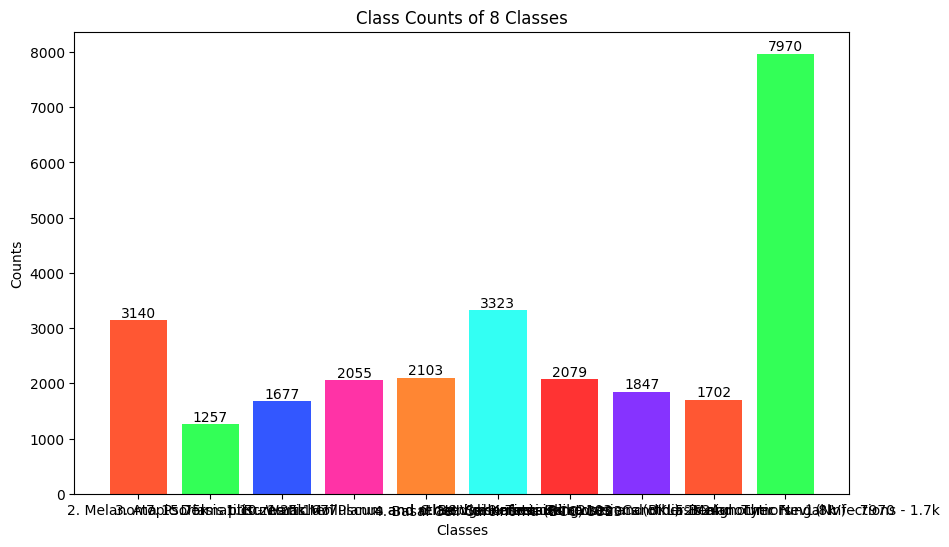

In [4]:
# Use the copied dataset
classes = os.listdir(output_path)
class_counts = [len(os.listdir(output_path + '/' + x)) for x in classes]
print("Class counts:", class_counts)


# Visualize class counts
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, class_counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6', 
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts of 8 Classes')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}',
        ha='center',
        va='bottom'
    )
plt.show()

In [5]:
from PIL import Image
import numpy as np

# Oversampler function
def oversampler(class_name, class_count, target=7000, batch_size=32, target_size=(240, 240)):
    # Initialize the ImageDataGenerator with augmentation settings
    datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    curr_dir = os.path.join(output_path, class_name)
    save_dir = curr_dir

    # Load images from the current class folder
    images = os.listdir(curr_dir)
    images = [os.path.join(curr_dir, img) for img in images]

    cnt = class_count
    target = target
    
    # Loop over images in batches, apply augmentation, and save them
    while cnt < target:
        batch_images = []
        
        # Load and resize images to the target size before converting to NumPy array
        for img_path in random.sample(images, batch_size):
            img = Image.open(img_path)
            img = img.resize(target_size)  # Resize the image
            img = np.array(img)  # Convert the PIL image to a NumPy array
            batch_images.append(img)

        batch_images = np.array(batch_images)  # Convert the list of images to a NumPy array

        # Process and augment the batch of images
        for _ in datagen.flow(batch_images, batch_size=batch_size, save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
            cnt += batch_size
            if cnt >= target:
                break
        
        print(f"Processed {cnt}/{target} images for {class_name}")

# Undersampler function
def undersampler(class_name, class_count, target_count=7000):
    curr_dir = os.path.join(output_path, class_name)
    images = os.listdir(curr_dir)

    # Calculate the number of images to delete
    images_to_delete = random.sample(images, class_count - target_count)

    # Delete images in batches
    for image in images_to_delete:
        img_path = os.path.join(curr_dir, image)
        try:
            os.remove(img_path)
        except Exception as e:
            print(f"Error deleting {img_path}: {e}")

    print(f"Deleted {len(images_to_delete)} images for {class_name}")

In [6]:
# Oversample or undersample each class
for i, class_name in enumerate(classes):
    if class_counts[i] < 7000:
        oversampler(class_name, class_counts[i])
    else:
        undersampler(class_name, class_counts[i])

print("Oversampling and undersampling completed successfully.")

Processed 7012/7000 images for 2. Melanoma 15.75k
Processed 7017/7000 images for 3. Atopic Dermatitis - 1.25k
Processed 7021/7000 images for 1. Eczema 1677
Processed 7015/7000 images for 7. Psoriasis pictures Lichen Planus and related diseases - 2k
Processed 7031/7000 images for 10. Warts Molluscum and other Viral Infections - 2103
Processed 7003/7000 images for 4. Basal Cell Carcinoma (BCC) 3323
Processed 7007/7000 images for 6. Benign Keratosis-like Lesions (BKL) 2624
Processed 7031/7000 images for 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Processed 7014/7000 images for 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
Deleted 970 images for 5. Melanocytic Nevi (NV) - 7970
Oversampling and undersampling completed successfully.


Class counts: [6983, 6968, 6988, 6974, 6989, 6984, 6973, 6985, 6973, 7000]


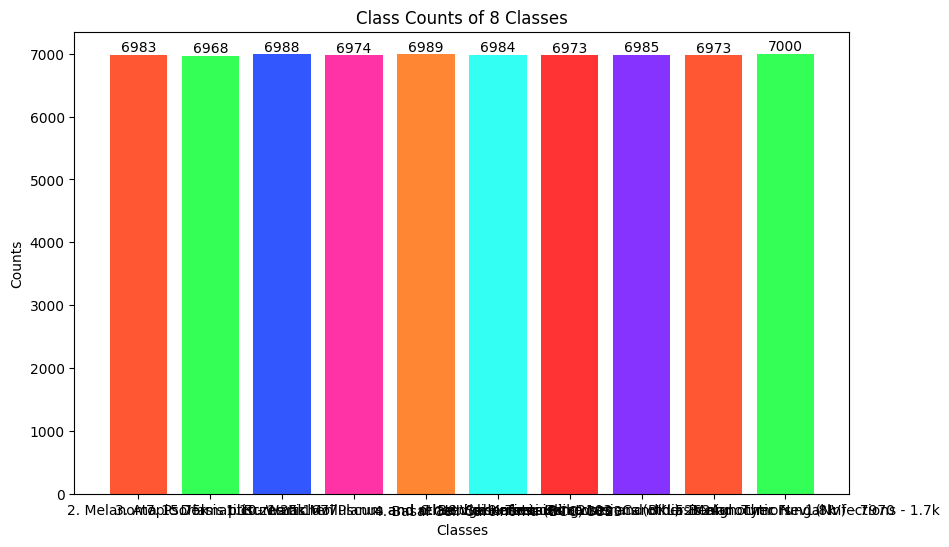

In [7]:
classes = os.listdir(output_path)
class_counts = [len(os.listdir(output_path + '/' + x)) for x in classes]
print("Class counts:", class_counts)


# Visualize class counts
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, class_counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6', 
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts of 8 Classes')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}',
        ha='center',
        va='bottom'
    )
plt.show()

In [8]:
import os
import random
import shutil

# Define paths for training, validation, and testing datasets
train_path = '/kaggle/working/train'
val_path = '/kaggle/working/val'
test_path = '/kaggle/working/test'

# Create directories for each dataset split
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Set the split ratios for train, validation, and test datasets
train_ratio = 0.8  # 70% for training
val_ratio = 0.10   # 15% for validation
test_ratio = 0.10  # 15% for testing

# Loop over each class in the output dataset and split it
for class_folder in os.listdir(output_path):  # using the output_path where dataset resides
    class_path = os.path.join(output_path, class_folder)
    
    # Create class directories in train, val, and test folders
    train_class_path = os.path.join(train_path, class_folder)
    val_class_path = os.path.join(val_path, class_folder)
    test_class_path = os.path.join(test_path, class_folder)
    
    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(val_class_path, exist_ok=True)
    os.makedirs(test_class_path, exist_ok=True)
    
    # List and shuffle the images in the current class folder
    images = os.listdir(class_path)
    random.shuffle(images)
    num_images = len(images)
    
    # Split the images based on the defined ratios
    num_train = int(num_images * train_ratio)
    num_val = int(num_images * val_ratio)
    num_test = num_images - num_train - num_val
    
    # Allocate images to each split
    train_images = images[:num_train]
    val_images = images[num_train:num_train + num_val]
    test_images = images[num_train + num_val:]
    
    # Copy images to the appropriate directories
    for image in train_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(train_class_path, image))
    
    for image in val_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(val_class_path, image))
    
    for image in test_images:
        shutil.copy(os.path.join(class_path, image), os.path.join(test_class_path, image))

print("Dataset split completed successfully.")

Dataset split completed successfully.


In [9]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Define image size and batch size
img_size = (224, 224)
batch_size = 32

# Paths to train and validation datasets (as defined in the previous steps)
train_path = '/kaggle/working/train'
val_path = '/kaggle/working/val'

# Create the train dataset
train_dataset = image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=123
)

# Get the class names from the training dataset
class_names = train_dataset.class_names

# Create the validation dataset
val_dataset = image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=42
)

# Display class names (optional)
print("Class Names:", class_names)

Found 55851 files belonging to 10 classes.


I0000 00:00:1775635528.536244      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775635528.543991      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 6977 files belonging to 10 classes.
Class Names: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [10]:
import tensorflow as tf
# Preprocessing function
@tf.function
def preprocess_image(image, label):
    # Resize the image
    image = tf.image.resize(image, [224, 224])
    # Apply EfficientNet preprocessing
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# Apply the preprocessing pipeline to the datasets
train_dataset = train_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

In [11]:
from keras.applications.efficientnet import preprocess_input


# Feature extractor
# Feature extractor using EfficientNetB0
base_model = keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3), 
    include_top=False,             
    weights='imagenet',
    pooling='max'
)

for layer in base_model.layers:
    layer.trainable = False

# Build model
inputs = base_model.input
x = BatchNormalization()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Flatten()(x)
outputs = Dense(10, activation='softmax')(x) #output layer 
model = Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="best_EfficientnetB0.weights.h5",   # Save only weights
    monitor="val_accuracy",                # You can also use 'val_loss'
    save_best_only=True,                   # Only overwrite when better result
    save_weights_only=True,                # Save weights (lighter file)
    verbose=1
)

# Train the model
epochs = 50
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stopping, lr_reduction, checkpoint]
)

# Load the best weights after training
model.load_weights("best_EfficientnetB0.weights.h5")


Epoch 1/50


I0000 00:00:1775635555.891657     140 service.cc:152] XLA service 0x7f26d00548a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775635555.891720     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775635555.891726     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775635558.338732     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-08 08:06:05.725917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:06:05.868887: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:06:06.206687: E external/local_xl

1745/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6849 - loss: 0.8982

2026-04-08 08:07:30.788043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:30.925334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:31.233715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:31.373589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:32.136017: E external/local_xla/xla/stream_

1746/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6849 - loss: 0.8981

2026-04-08 08:07:58.448255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:58.583187: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:59.341109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:07:59.475611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.87143, saving model to best_EfficientnetB0.weights.h5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 137s 63ms/step - accuracy: 0.6850 - loss: 0.8979 - val_accuracy: 0.8714 - val_loss: 0.3612 - learning_rate: 1.0000e-04
Epoch 2/50
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8776 - loss: 0.3401
Epoch 2: val_accuracy improved from 0.87143 to 0.89207, saving model to best_EfficientnetB0.weights.h5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.8776 - loss: 0.3401 - val_accuracy: 0.8921 - val_loss: 0.3080 - learning_rate: 1.0000e-04
Epoch 3/50
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8989 - loss: 0.2740
Epoch 3: val_accuracy improved from 0.89207 to 0.89465, saving model to best_EfficientnetB0.weights.h5
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.8989 - loss: 0.2740 - val_accuracy: 0.8947 - val_loss: 0.3062 - learning_rate: 1.0000e-04
Epoch 4/50
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 

In [13]:
# Save the model after training
model_save_path = '/kaggle/working/EfficientnetB0.h5'
model.save(model_save_path)

# Optionally, display a message confirming the model is saved
print(f'Model saved at {model_save_path}')

Model saved at /kaggle/working/EfficientnetB0.h5


Found 6989 files belonging to 10 classes.


2026-04-08 08:20:54.046843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:20:54.185948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:20:54.505119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:20:54.646394: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 08:20:55.407977: E external/local_xla/xla/stream_

Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.92      0.91      0.92       700
           10. Warts Molluscum and other Viral Infections - 2103       0.89      0.90      0.90       700
                                              2. Melanoma 15.75k       0.97      0.96      0.96       699
                                    3. Atopic Dermatitis - 1.25k       0.91      0.91      0.91       698
                              4. Basal Cell Carcinoma (BCC) 3323       0.91      0.96      0.93       699
                                 5. Melanocytic Nevi (NV) - 7970       0.91      0.92      0.92       700
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.93      0.88      0.91       698
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.89      0.85      0.87       698
          8. Seborrhe

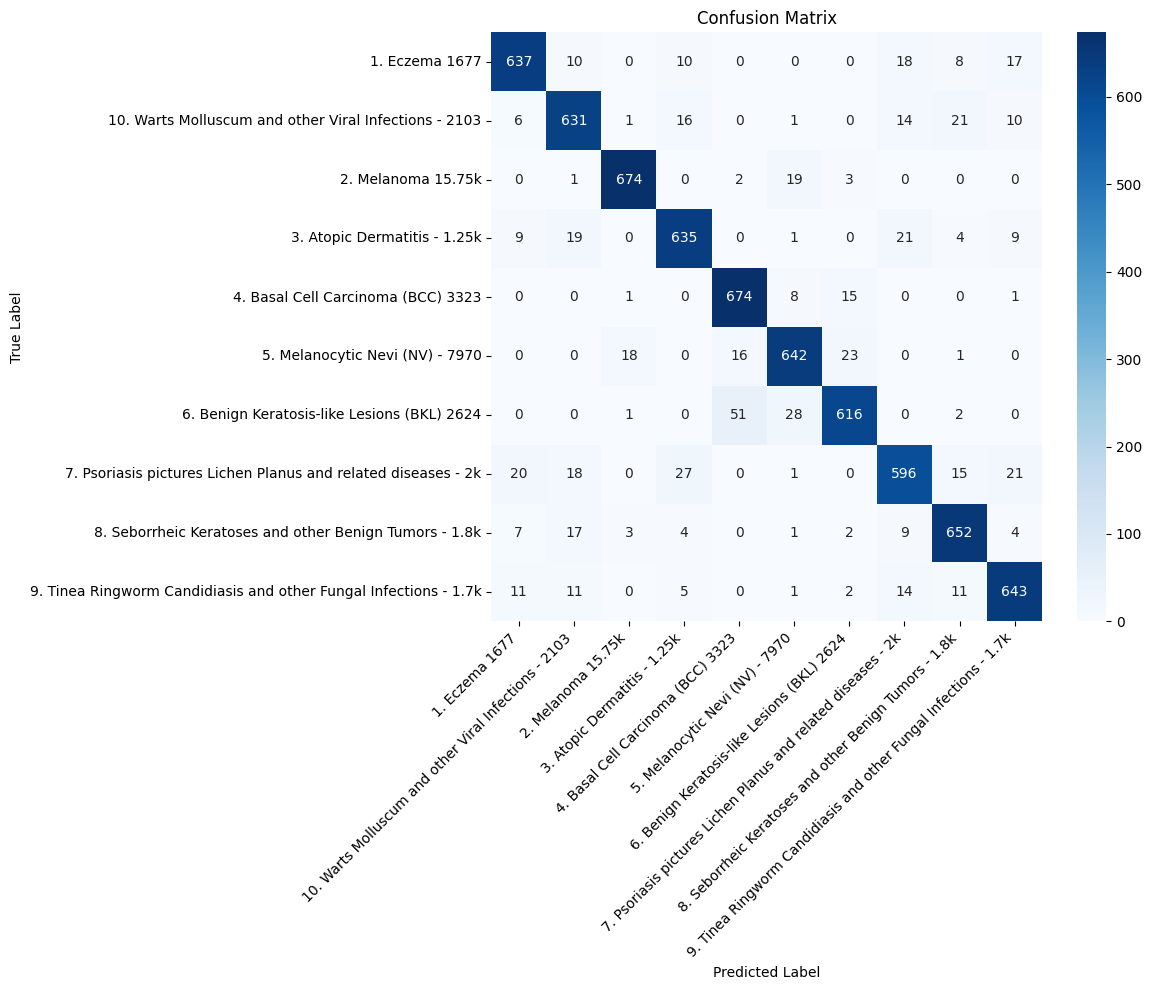

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load test dataset first WITHOUT mapping
raw_test_dataset = image_dataset_from_directory(
    '/kaggle/working/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False  # Critical for matching predictions to labels
)

# Save class names before mapping
class_names = raw_test_dataset.class_names

# Now map and prefetch
test_dataset = raw_test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

# Predict and gather labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.92      0.91      0.92       700
           10. Warts Molluscum and other Viral Infections - 2103       0.89      0.90      0.90       700
                                              2. Melanoma 15.75k       0.97      0.96      0.96       699
                                    3. Atopic Dermatitis - 1.25k       0.91      0.91      0.91       698
                              4. Basal Cell Carcinoma (BCC) 3323       0.91      0.96      0.93       699
                                 5. Melanocytic Nevi (NV) - 7970       0.91      0.92      0.92       700
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.93      0.88      0.91       698
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.89      0.85      0.87       698
          8. Seborrhe

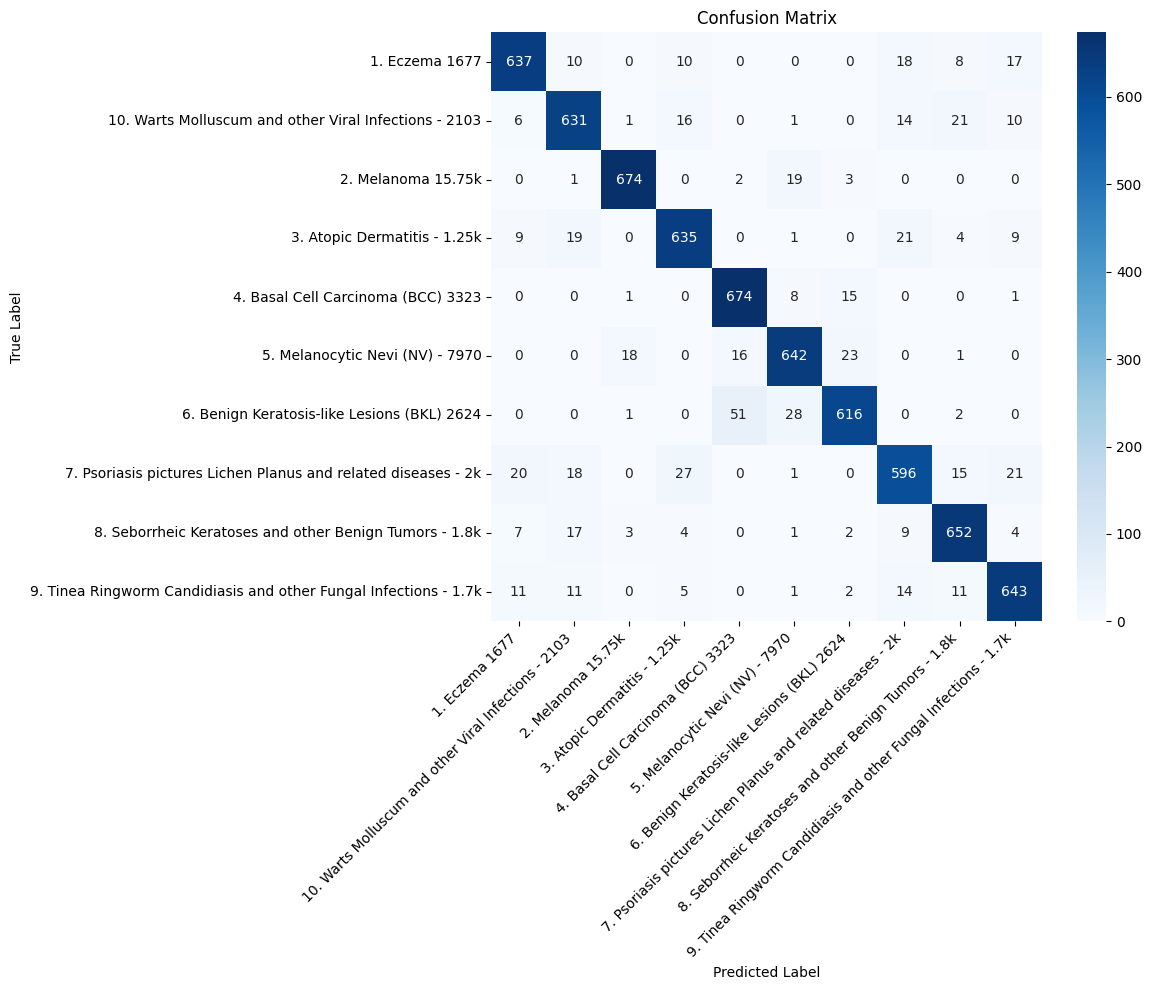

In [16]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []
y_prob = []  # Store probabilities for ROC-AUC

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_prob.extend(preds)  # softmax probabilities

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

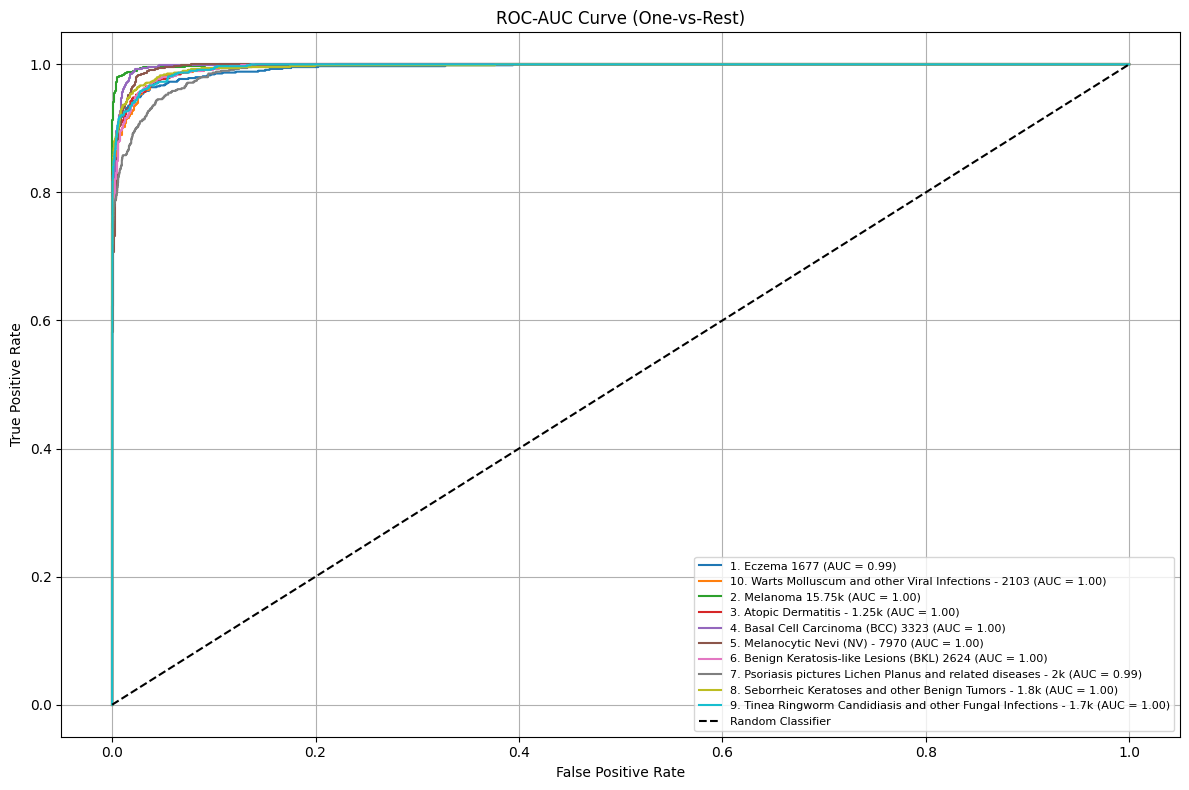


Mean AUC Score: 0.9961


In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multiclass ROC
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

plt.figure(figsize=(12, 8))
auc_scores = []

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMean AUC Score: {np.mean(auc_scores):.4f}")

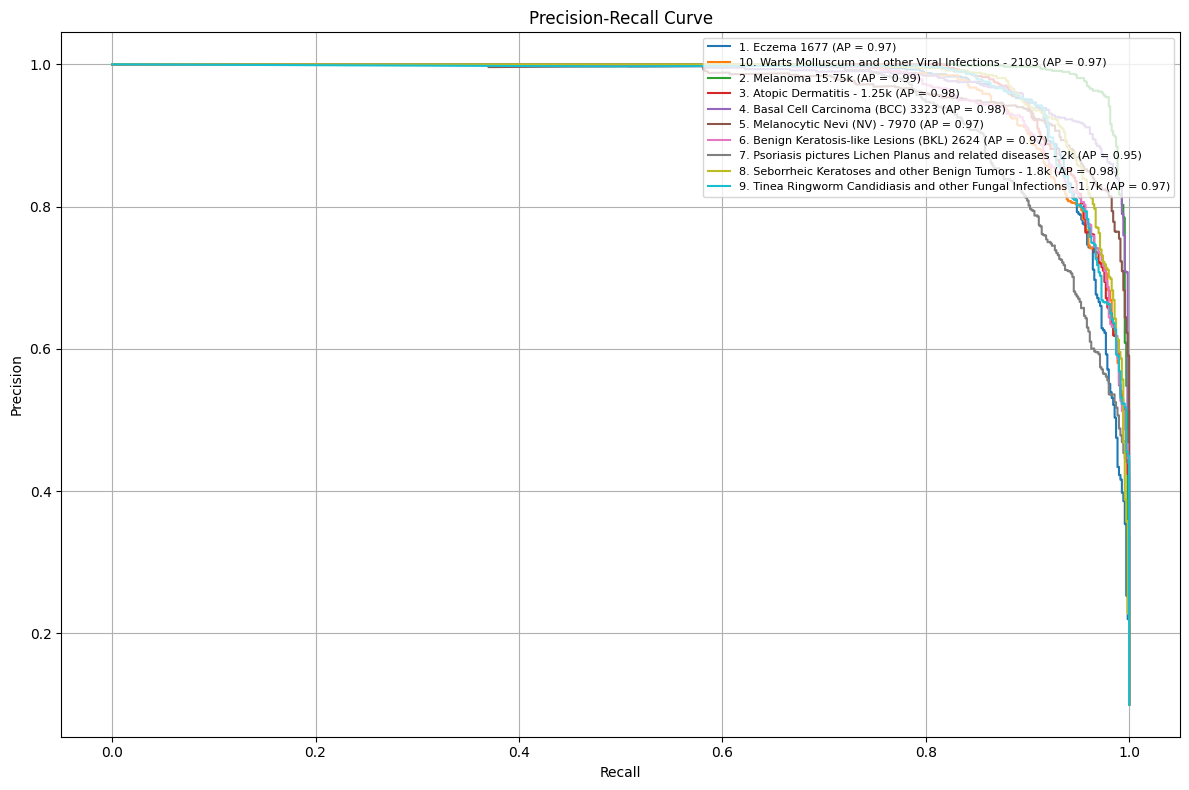


Mean Average Precision (mAP): 0.9747


In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(12, 8))
ap_scores = []

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    ap_scores.append(ap)
    plt.plot(recall, precision, label=f'{class_names[i]} (AP = {ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nMean Average Precision (mAP): {np.mean(ap_scores):.4f}")

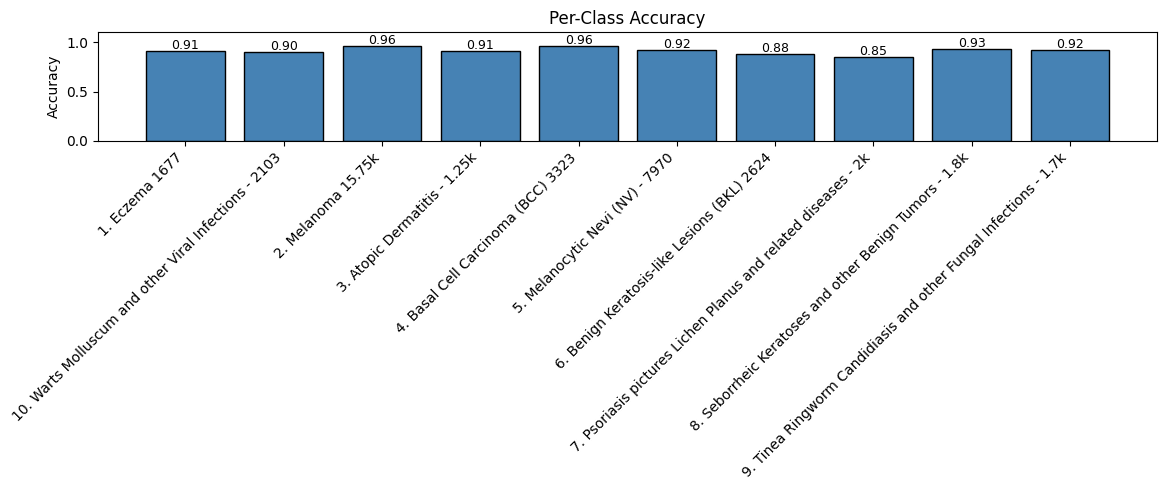


===== Overall Metrics Summary =====
Accuracy:              0.9157
Balanced Accuracy:     0.9157
Macro F1-Score:        0.9156
Weighted F1-Score:     0.9156
Mean AUC:              0.9961
Mean Avg Precision:    0.9747


In [19]:
from sklearn.metrics import balanced_accuracy_score

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Overall metrics summary
from sklearn.metrics import accuracy_score, f1_score
print("\n===== Overall Metrics Summary =====")
print(f"Accuracy:              {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced Accuracy:     {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1-Score:        {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1-Score:     {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Mean AUC:              {np.mean(auc_scores):.4f}")
print(f"Mean Avg Precision:    {np.mean(ap_scores):.4f}")